***# Setup and load clean data:***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make all plots look professional
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load clean datasets
crop_df = pd.read_csv('crop_clean.csv')
rain_df = pd.read_csv('rain_clean.csv')
temp_df = pd.read_csv('temp_clean.csv')
water_df = pd.read_csv('water_clean.csv')

print("✓ All clean datasets loaded")
print(f"  Crop: {crop_df.shape} | Rain: {rain_df.shape} | Temp: {temp_df.shape} | Water: {water_df.shape}")

✓ All clean datasets loaded
  Crop: (288991, 8) | Rain: (4188, 19) | Temp: (33, 18) | Water: (194, 21)


***# Top and bottom states by average yield:***

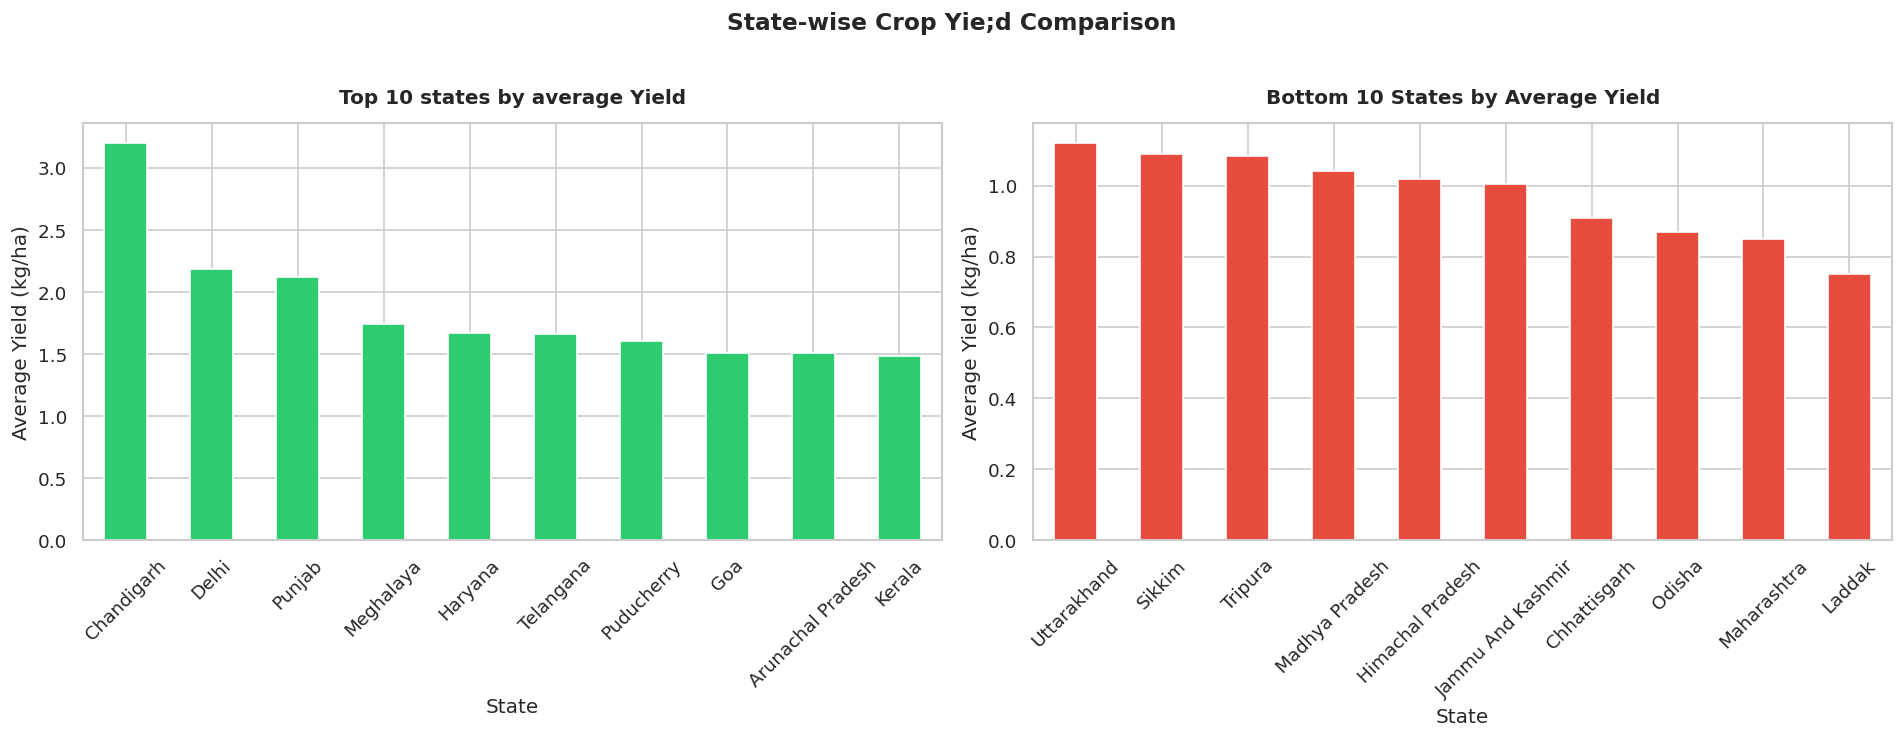


Top 5 states:
State
Chandigarh    3.198353
Delhi         2.184512
Punjab        2.120074
Meghalaya     1.743446
Haryana       1.666600
Name: Yield, dtype: float64

Bottom 5 states:
State
Jammu And Kashmir    1.005461
Chhattisgarh         0.909436
Odisha               0.868489
Maharashtra          0.848681
Laddak               0.750915
Name: Yield, dtype: float64


In [5]:
# Average yield per state across all crop and yrear
state_yield = crop_df.groupby('State')['Yield'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TOP 10
state_yield.head(10).plot(kind='bar', ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('Top 10 states by average Yield', fontweight='bold', pad=12)
axes[0].set_xlabel('State')
axes[0].set_ylabel('Average Yield (kg/ha)')
axes[0].tick_params(axis='x', rotation=45)

# BOTTOM 10
state_yield.tail(10).plot(kind='bar', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Bottom 10 States by Average Yield', fontweight='bold', pad=12)
axes[1].set_xlabel('State')
axes[1].set_ylabel('Average Yield (kg/ha)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('State-wise Crop Yie;d Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_state_yield.png', bbox_inches='tight')
plt.show()


print("\nTop 5 states:")
print(state_yield.head())
print("\nBottom 5 states:")
print(state_yield.tail())

***# National yield trend over time:***

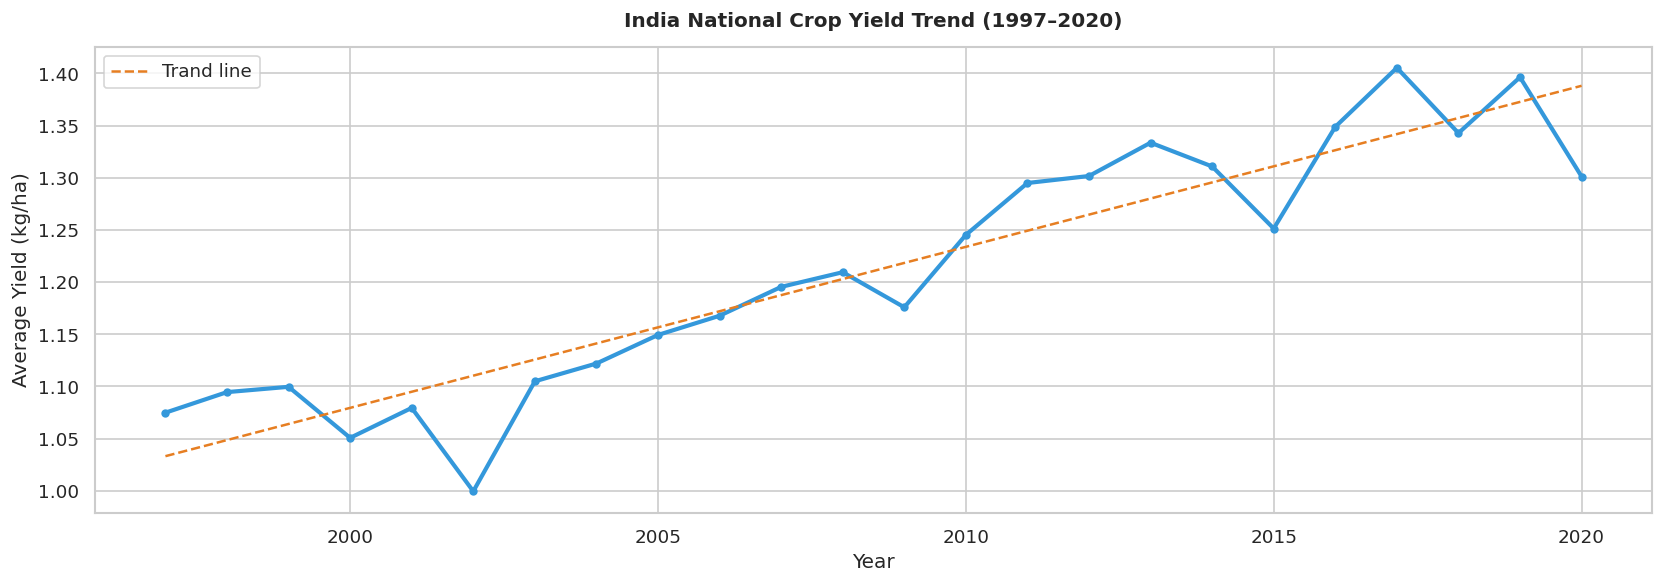

Trend slope: 0.02 kg/ha per year
Direction: ↑ Increasing


In [6]:
# How has India's overall crop yield changed year by year?
yearly_yield = crop_df.groupby('Crop_Year')['Yield'].mean()

plt.figure(figsize=(14, 5))
plt.plot(yearly_yield.index, yearly_yield.values, color='#3498db',
         linewidth=2.5, marker='o', markersize=4)

# ADD a trend line
z = np.polyfit(yearly_yield.index, yearly_yield.values, 1)
p = np.poly1d(z)
plt.plot(yearly_yield.index, p(yearly_yield.index),
         '--', color='#e67e22', linewidth=1.5, label='Trand line')

plt.title('India National Crop Yield Trend (1997–2020)', fontweight='bold', pad=12)
plt.xlabel('Year')
plt.ylabel('Average Yield (kg/ha)')
plt.legend()
plt.tight_layout()
plt.savefig('plot2_yield_trend.png', bbox_inches='tight')
plt.show()

# Is yield going up or down?
slope = z[0]
print(f"Trend slope: {slope:.2f} kg/ha per year")
print(f"Direction: {'↑ Increasing' if slope > 0 else '↓ Decreasing'}")

***# Which crops dominat by area:***

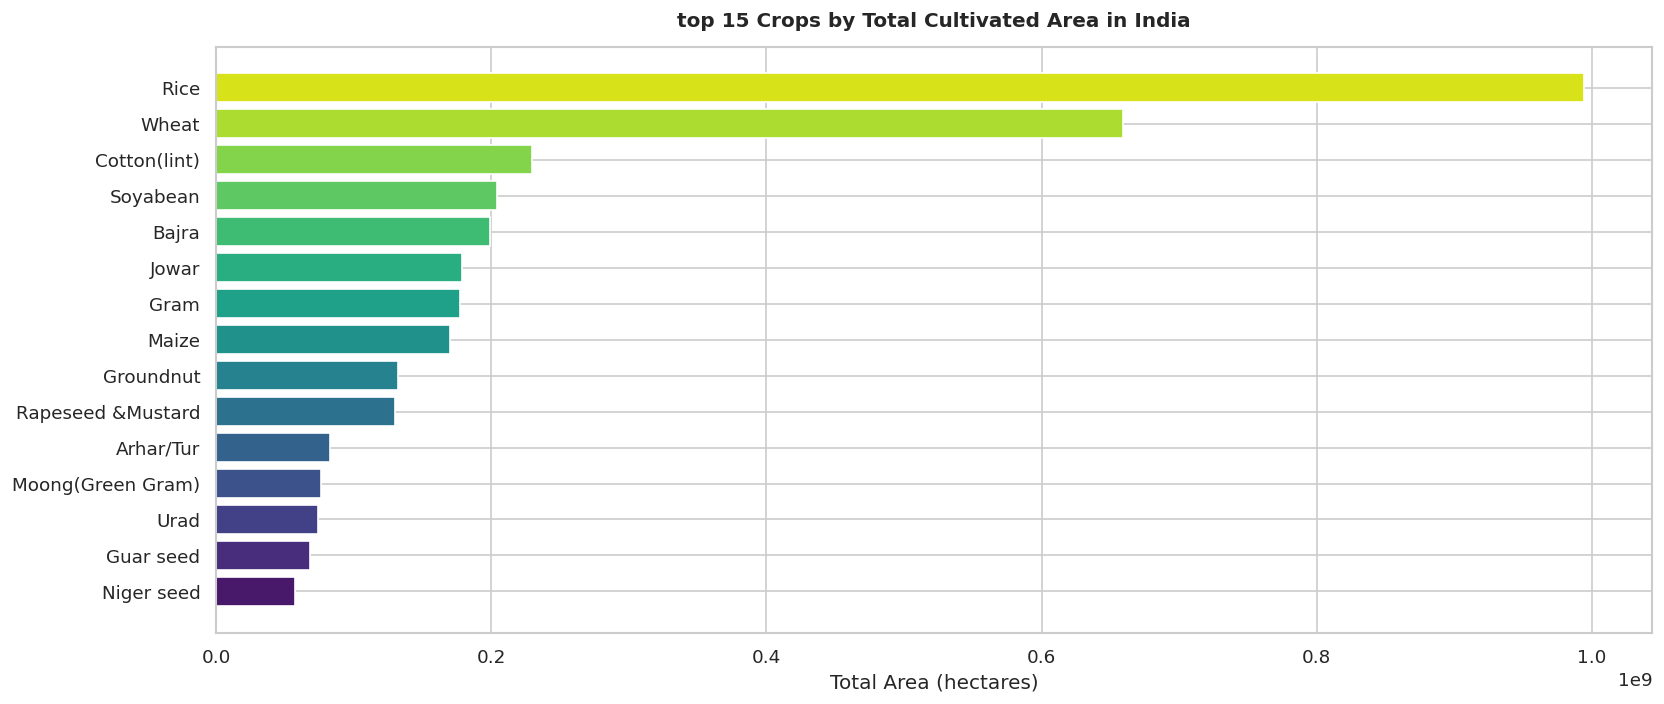

In [7]:
# Top 15 crops by total cultivatied area
top_crops_area = crop_df.groupby('Crop')['Area'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
bars = plt.barh(top_crops_area.index[::-1], top_crops_area.values[::-1],
                color=sns.color_palette('viridis', 15))
plt.title('top 15 Crops by Total Cultivated Area in India', fontweight='bold',pad=12)
plt.xlabel('Total Area (hectares)')
plt.tight_layout()
plt.savefig('plot3_crop_area.png', bbox_inches='tight')
plt.show()

***# Season-wise production breakdown:***

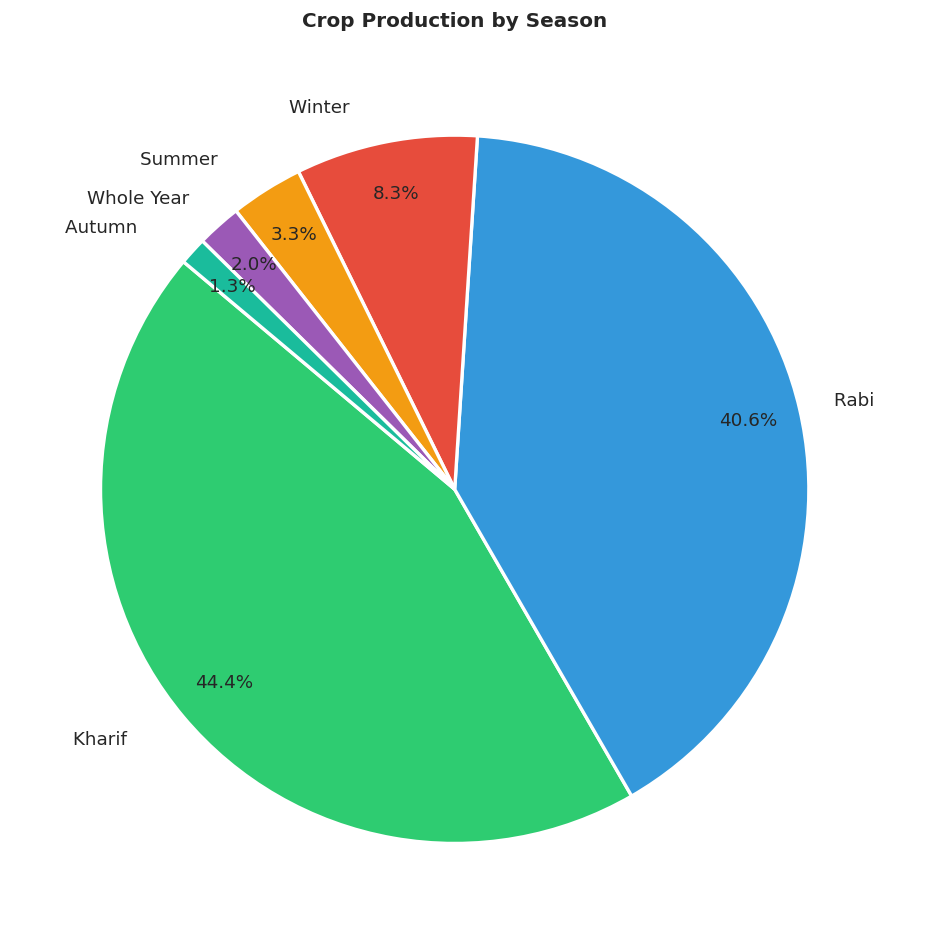

Production by season:
Season
Kharif         2.934126e+09
Rabi           2.683740e+09
Winter         5.481435e+08
Summer         2.193372e+08
Whole Year     1.340613e+08
Autumn         8.320342e+07
Name: Production, dtype: float64


In [11]:
# which season contributes most to total production?
season_prod = crop_df.groupby('Season')['Production'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
plt.pie(season_prod.values, labels=season_prod.index,
        autopct='%1.1f%%', colors=colors,
        startangle=140, pctdistance=0.85,
        wedgeprops=dict(edgecolor='white', linewidth=2))
plt.title('Crop Production by Season', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot4_season_pie.png', bbox_inches='tight')
plt.show()

print("Production by season:")
print(season_prod)

***# Rainfall vs Yield (the key relationship):***

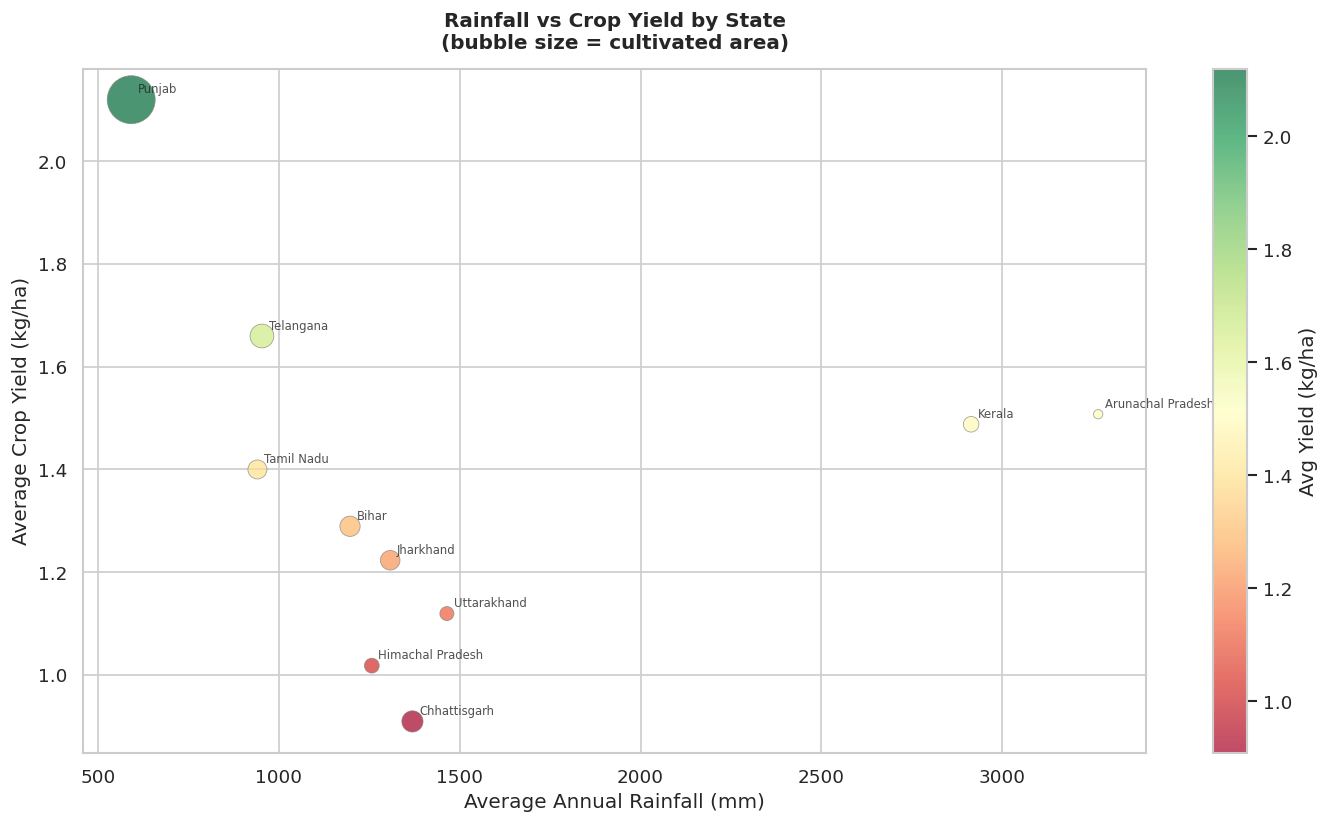

Correlation between rainfall and yield: -0.088
Interpretation: Negative relationship
Strength: Weak


In [12]:
# First we need to aggregate crop data to state level
# (rainfall is by subdivision, we'll do a simple state-level crop aggregation)
state_crop_avg = crop_df.groupby('State').agg(
    avg_yield=('Yield', 'mean'),
    avg_area=('Area', 'mean')
).reset_index()

# Aggregate rainfall to state level (annual average across all years)
state_rain_avg = rain_df.groupby('SUBDIVISION')['ANNUAL'].mean().reset_index()
state_rain_avg.columns = ['State', 'avg_annual_rainfall']

# Simple merge on state name (we'll do the full proper merge in Week 5)
merged = pd.merge(state_crop_avg, state_rain_avg,
                  left_on='State', right_on='State', how='inner')

plt.figure(figsize=(12, 7))
scatter = plt.scatter(merged['avg_annual_rainfall'], merged['avg_yield'],
                      s=merged['avg_area']/50,   # bubble size = area cultivated
                      alpha=0.7, c=merged['avg_yield'],
                      cmap='RdYlGn', edgecolors='grey', linewidth=0.5)

# Label each bubble with state name
for _, row in merged.iterrows():
    plt.annotate(row['State'],
                 (row['avg_annual_rainfall'], row['avg_yield']),
                 fontsize=7, alpha=0.8,
                 xytext=(4, 4), textcoords='offset points')

plt.colorbar(scatter, label='Avg Yield (kg/ha)')
plt.title('Rainfall vs Crop Yield by State\n(bubble size = cultivated area)',
          fontweight='bold', pad=12)
plt.xlabel('Average Annual Rainfall (mm)')
plt.ylabel('Average Crop Yield (kg/ha)')
plt.tight_layout()
plt.savefig('plot5_rainfall_vs_yield.png', bbox_inches='tight')
plt.show()

# Calculate correlation coefficient
corr = merged['avg_annual_rainfall'].corr(merged['avg_yield'])
print(f"Correlation between rainfall and yield: {corr:.3f}")
print(f"Interpretation: {'Positive' if corr > 0 else 'Negative'} relationship")
print(f"Strength: {'Strong' if abs(corr) > 0.6 else 'Moderate' if abs(corr) > 0.3 else 'Weak'}")

***# The Correlation heatmap:***

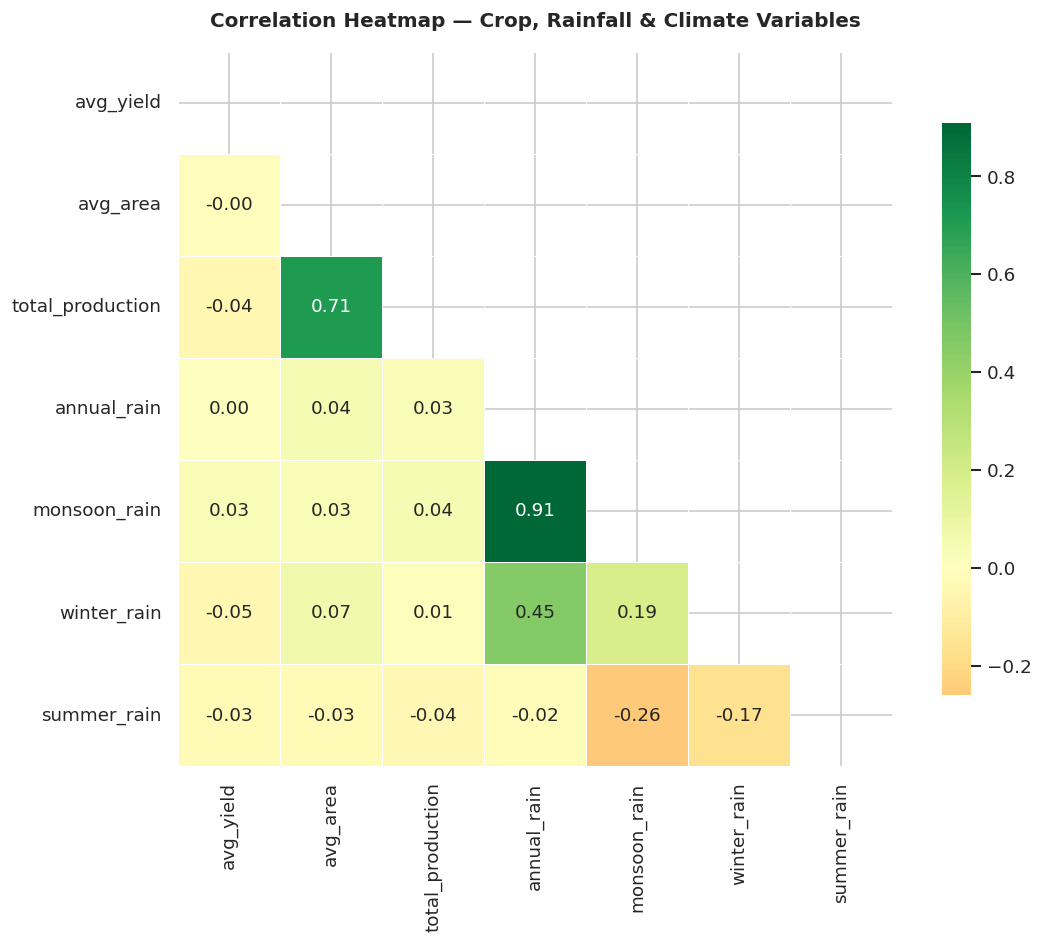


Correlation with avg_yield:
avg_yield           1.000000
monsoon_rain        0.031035
annual_rain         0.001811
avg_area           -0.004422
summer_rain        -0.028952
total_production   -0.044032
winter_rain        -0.046197
Name: avg_yield, dtype: float64


In [13]:
# Build a numeric summary dataframe for correlation
# Aggregate crop data by state and year
crop_summary = crop_df.groupby(['State', 'Crop_Year']).agg(
    avg_yield       = ('Yield', 'mean'),
    avg_area        = ('Area', 'mean'),
    total_production= ('Production', 'sum')
).reset_index()

# Aggregate rainfall by subdivision (use ANNUAL + seasonal columns)
rain_summary = rain_df.groupby('YEAR').agg(
    annual_rain = ('ANNUAL', 'mean'),
    monsoon_rain= ('JJAS', 'mean'),
    winter_rain = ('OND', 'mean'),
    summer_rain = ('MAM', 'mean')
).reset_index()
rain_summary = rain_summary.rename(columns={'YEAR': 'Crop_Year'})

# Merge crop + rainfall on year
corr_df = pd.merge(crop_summary, rain_summary, on='Crop_Year', how='inner')

# Select only numeric columns for correlation
numeric_cols = ['avg_yield', 'avg_area', 'total_production',
                'annual_rain', 'monsoon_rain', 'winter_rain', 'summer_rain']

corr_matrix = corr_df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide upper triangle (it's a mirror)
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,           # show numbers inside squares
            fmt='.2f',            # round to 2 decimals
            cmap='RdYlGn',        # red=negative, green=positive
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Crop, Rainfall & Climate Variables',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot6_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("\nCorrelation with avg_yield:")
print(corr_matrix['avg_yield'].sort_values(ascending=False))

***# Yield distribution by crop(Focus: Rice & Wheat):***

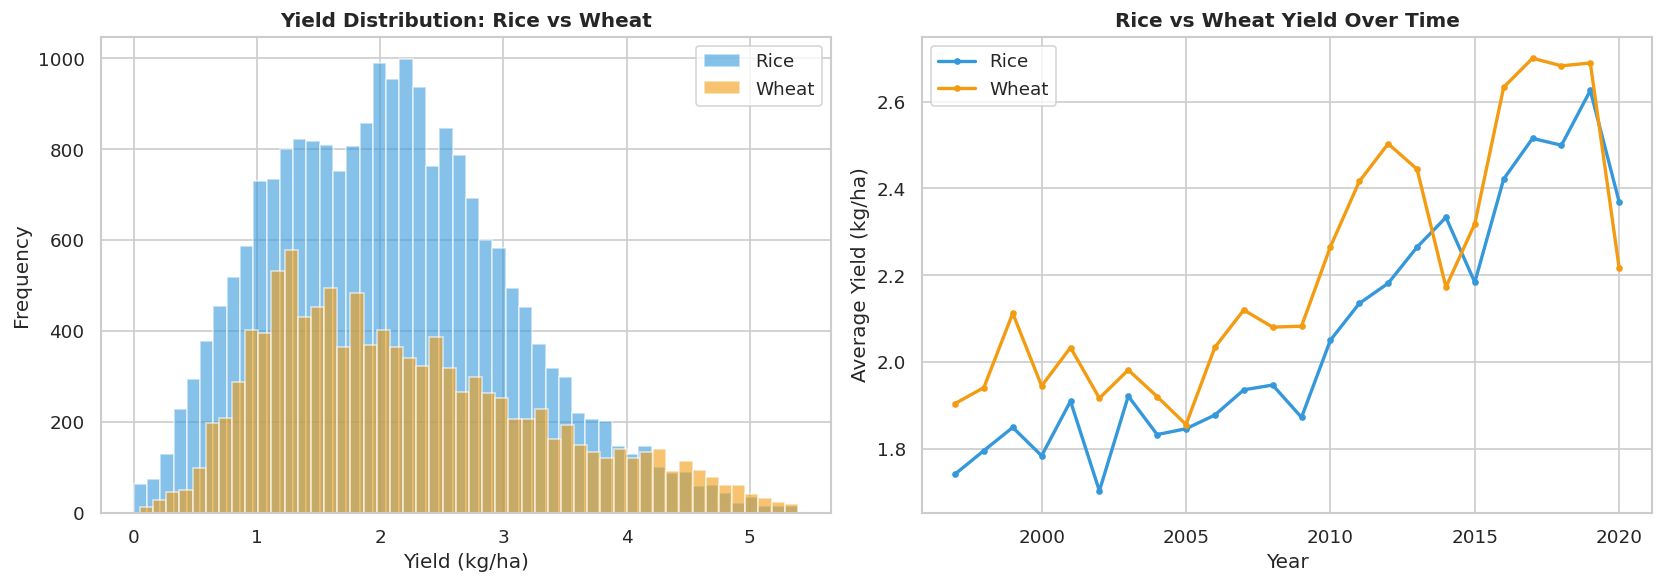

In [14]:
# Focus on the two most important crops
focus_crops = crop_df[crop_df['Crop'].isin(['Rice', 'Wheat'])]

plt.figure(figsize=(14, 5))

# Left: Distribution of yields
plt.subplot(1, 2, 1)
for crop, color in [('Rice', '#3498db'), ('Wheat', '#f39c12')]:
    data = focus_crops[focus_crops['Crop'] == crop]['Yield']
    plt.hist(data, bins=50, alpha=0.6, color=color, label=crop, edgecolor='white')
plt.title('Yield Distribution: Rice vs Wheat', fontweight='bold')
plt.xlabel('Yield (kg/ha)')
plt.ylabel('Frequency')
plt.legend()

# Right: Year-wise yield comparison
plt.subplot(1, 2, 2)
for crop, color in [('Rice', '#3498db'), ('Wheat', '#f39c12')]:
    yearly = focus_crops[focus_crops['Crop'] == crop].groupby('Crop_Year')['Yield'].mean()
    plt.plot(yearly.index, yearly.values, color=color, linewidth=2, label=crop, marker='o', markersize=3)
plt.title('Rice vs Wheat Yield Over Time', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Yield (kg/ha)')
plt.legend()

plt.tight_layout()
plt.savefig('plot7_rice_wheat_comparison.png', bbox_inches='tight')
plt.show()

***# Save EDA summary as a findings report***

In [15]:
print("=" * 60)
print("EDA FINDINGS SUMMARY — AGRI-CLIMATE PROJECT")
print("=" * 60)

print(f"\n1. DATASET OVERVIEW")
print(f"   Total crop records analysed: {len(crop_df):,}")
print(f"   States covered: {crop_df['State'].nunique()}")
print(f"   Crops covered: {crop_df['Crop'].nunique()}")
print(f"   Year range: {crop_df['Crop_Year'].min()} – {crop_df['Crop_Year'].max()}")

print(f"\n2. YIELD INSIGHTS")
print(f"   Highest yielding state: {state_yield.idxmax()} ({state_yield.max():.1f} kg/ha)")
print(f"   Lowest yielding state:  {state_yield.idxmin()} ({state_yield.min():.1f} kg/ha)")
print(f"   National average yield: {crop_df['Yield'].mean():.1f} kg/ha")

print(f"\n3. TREND")
print(f"   Yield trend: {slope:.2f} kg/ha per year ({'Improving' if slope > 0 else 'Declining'})")

print(f"\n4. RAINFALL-YIELD RELATIONSHIP")
print(f"   Correlation coefficient: {corr:.3f}")

print(f"\n5. TOP CROP BY AREA")
print(f"   {top_crops_area.index[0]} ({top_crops_area.values[0]:,.0f} hectares)")

print("\n" + "=" * 60)
print("Plots saved: plot1 through plot7")

EDA FINDINGS SUMMARY — AGRI-CLIMATE PROJECT

1. DATASET OVERVIEW
   Total crop records analysed: 288,991
   States covered: 36
   Crops covered: 55
   Year range: 1997 – 2020

2. YIELD INSIGHTS
   Highest yielding state: Chandigarh (3.2 kg/ha)
   Lowest yielding state:  Laddak (0.8 kg/ha)
   National average yield: 1.2 kg/ha

3. TREND
   Yield trend: 0.02 kg/ha per year (Improving)

4. RAINFALL-YIELD RELATIONSHIP
   Correlation coefficient: -0.088

5. TOP CROP BY AREA
   Rice (994,159,144 hectares)

Plots saved: plot1 through plot7
